<a href="https://colab.research.google.com/github/qji25002/A04_qji25002/blob/main/A04_xAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A04: Model Interpretability (xAI)
-----------------------------------
**Eldhose Kochakkan Varghesekutty:**

You previously worked with this dataset on the 'Sampling' notebooks. Now, you will try to interpret the model!

You will build a classification model of your choice (you may use SMOTE or not - I'm not testing how good your model is for this assignment, just that you know how to interpret the model!). You must do some form of autoML or grid search...

The target variable is Loan_Status (thanks Ahmend for the heads-up!)

Then you will:
* Print the Top 5 features (using permutation importance with 20 repeats) in a box plot.
* Create the partial dependence plots for the top 5 features (you may opt to use the num_grid_points argument). Customize the plots so that the Y axis is consistent on each of the five plots.
* Write five meaningful bullets about what you see in the plots. Does anything surprise you? What do the X and Y axis mean in each plot?
  * Optional: Any issues with correlated predictors (read here for a cool way on how to address this: https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html)?

In [42]:
#https://drive.google.com/file/d/1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W/view?usp=share_link
!gdown 1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W

Downloading...
From: https://drive.google.com/uc?id=1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W
To: /content/train_loan_imbalanced.csv
100% 38.0k/38.0k [00:00<00:00, 51.7MB/s]


In [43]:
import pandas as pd
df = pd.read_csv('/content/train_loan_imbalanced.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# 1. Import libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import accuracy_score, classification_report

# Prepare the data

In [45]:
# Loan_ID is only an identifier
df.drop('Loan_ID', axis=1, inplace=True)

# encode target
LE = LabelEncoder()
df['Loan_Status'] = LE.fit_transform(df['Loan_Status'])

print(LE.classes_)

['N' 'Y']


handle the missing values:

In [46]:
# categorical columns
categorical_cols = df.drop('Loan_Status', axis=1).select_dtypes(include='object').columns

# numerical columns
numeric_cols = df.drop('Loan_Status', axis=1).select_dtypes(exclude='object').columns

# fill categorical missing values
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# fill numerical missing values
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

Convert categorical predictors to dummy variables:

In [47]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,1,0,0,0,0,0,0,0,1
1,4583,1508.0,128.0,360.0,1.0,0,1,1,1,0,0,0,0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1,1,0,0,0,0,1,0,1
3,2583,2358.0,120.0,360.0,1.0,1,1,1,0,0,0,1,0,0,1
4,6000,0.0,141.0,360.0,1.0,1,1,0,0,0,0,0,0,0,1


# Create x and y

In [48]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

print(X.shape)
print(y.shape)

(614, 14)
(614,)


# Train/test split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(491, 14) (123, 14) (491,) (123,)


# Grid Search classification model

In [50]:
RF = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RF,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

Check the selected model

In [51]:
print("Best Parameters:")
print(grid_search.best_params_)

clf = grid_search.best_estimator_

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


# Top 5 features using permutation importance with 20 repeats

# Permutation importance

In [52]:
result = permutation_importance(
    clf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

perm_sorted_idx = result.importances_mean.argsort()

# Get Top 5

In [53]:
top_5_idx = perm_sorted_idx[-5:]

top_5_features = X.columns[top_5_idx]

print("Top 5 Features:")

for feature in top_5_features[::-1]:
    print(feature)

Top 5 Features:
Credit_History
Property_Area_Urban
ApplicantIncome
Education_Not Graduate
Self_Employed_Yes


# Top 5 boxplot

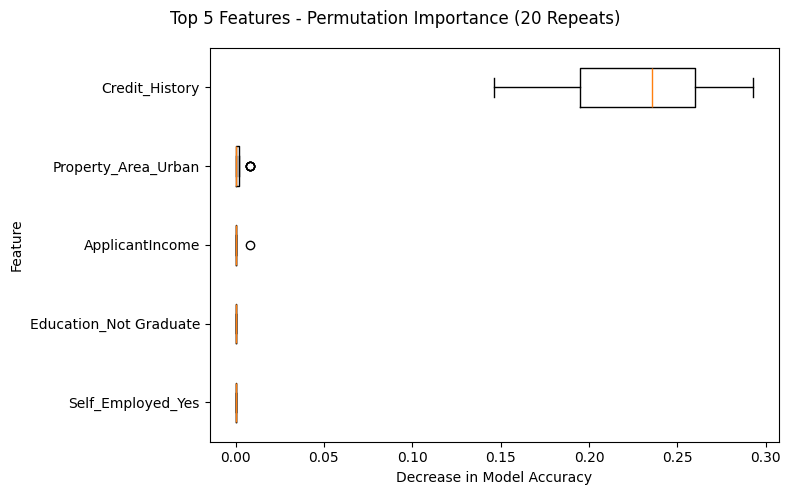

In [54]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(8, 5)
)

ax.boxplot(
    result.importances[top_5_idx].T,
    vert=False,
    tick_labels=X.columns[top_5_idx]
)

ax.set_xlabel("Decrease in Model Accuracy")
ax.set_ylabel("Feature")

fig.suptitle(
    "Top 5 Features - Permutation Importance (20 Repeats)"
)

fig.tight_layout()

plt.show()

# Partial Dependence Plots for Top 5

In [55]:
!pip install -q pycebox

  Preparing metadata (setup.py) ... done


In [56]:
from pycebox.ice import ice, ice_plot

# Prepare training data

In [57]:
train_X_df = X_train.copy()

In [59]:
def predict_loan_probability(data):
    return clf.predict_proba(data)[:, 1]

In [60]:
top_5_features = list(top_5_features[::-1])

print(top_5_features)

['Credit_History', 'Property_Area_Urban', 'ApplicantIncome', 'Education_Not Graduate', 'Self_Employed_Yes']


# Generate ICE/PDP data

In [64]:
def predict_loan_probability(data):

    data = pd.DataFrame(
        data,
        columns=X_train.columns
    )

    return clf.predict_proba(data)[:, 1]

In [65]:
train_ice_dfs = {}

for feature in top_5_features:

    train_ice_dfs[feature] = ice(
        data=train_X_df,
        column=feature,
        predict=predict_loan_probability,
        num_grid_points=20
    )

# Plot the five PDPs

In [62]:
sharey=True

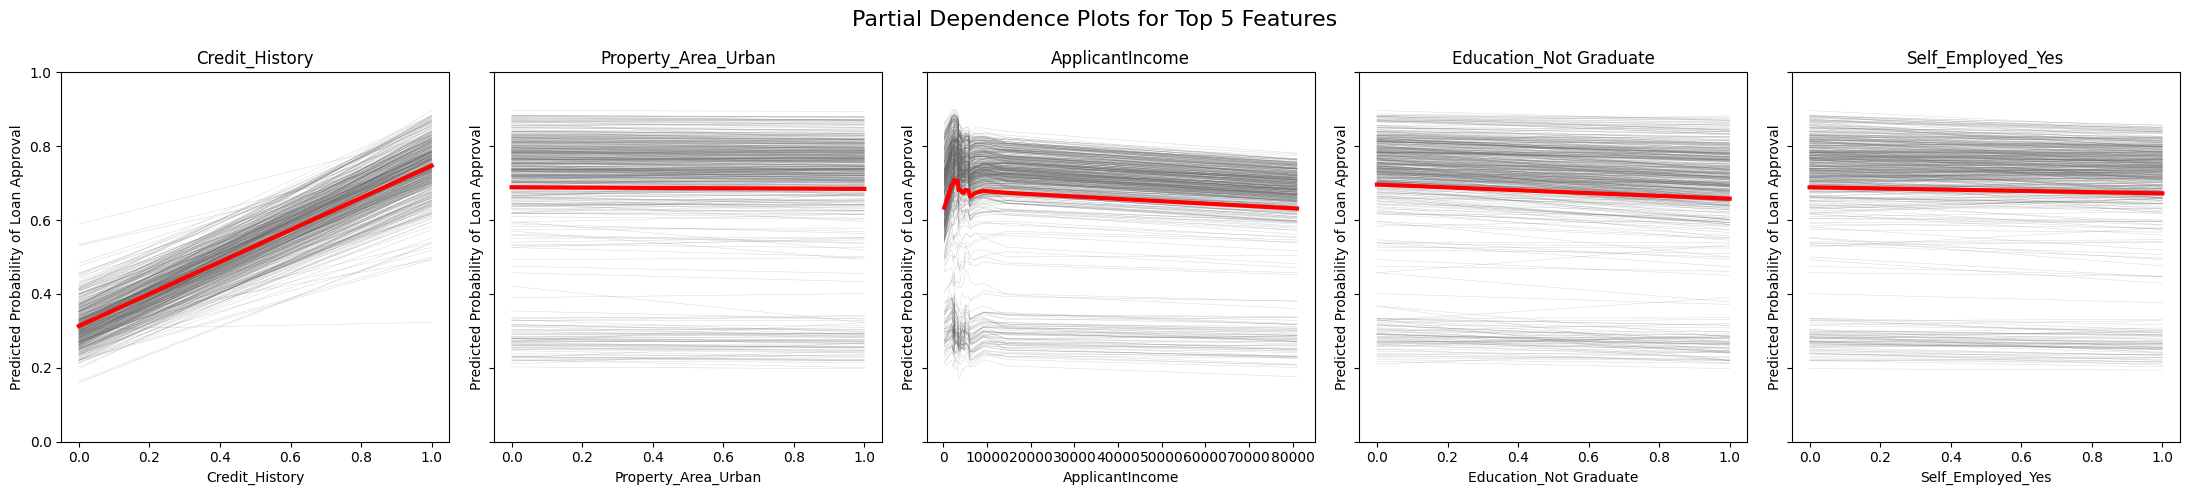

In [63]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 5),
    sharey=True
)

for feature, ax in zip(top_5_features, axes):

    ice_plot(
        train_ice_dfs[feature],
        ax=ax,
        c='dimgray',
        linewidth=0.3,
        alpha=0.3,
        plot_pdp=True,
        pdp_kwargs={
            'linewidth': 3,
            'color': 'red'
        }
    )

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Predicted Probability of Loan Approval")

    # same Y-axis on every plot
    ax.set_ylim(0, 1)

fig.suptitle(
    "Partial Dependence Plots for Top 5 Features",
    fontsize=16
)

fig.subplots_adjust(top=0.82)

plt.tight_layout()

plt.show()

- **Credit_History** has the strongest effect. The predicted probability of loan approval increases a lot when Credit_History changes from 0 to 1.

- **Property_Area_Urban** has very little effect. The PDP is almost flat, so being in an urban area does not change the prediction much.

- **ApplicantIncome** has a small nonlinear effect. The approval probability changes more at lower income values, then gradually decreases as income increases.

- **Education_Not Graduate** has only a small negative effect. The predicted approval probability decreases slightly when the value changes from 0 to 1.

- **Self_Employed_Yes** also has very little effect. The line is nearly flat, which means self-employment does not strongly influence the model compared with Credit_History.

In all five plots, the **X-axis shows the value of the feature**, and the **Y-axis shows the predicted probability of loan approval**.